<a href="https://colab.research.google.com/github/shouib09/Machine-Learning-Lab/blob/main/house_price_exp_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

R-squared: 0.8037 | MSE: 0.2573


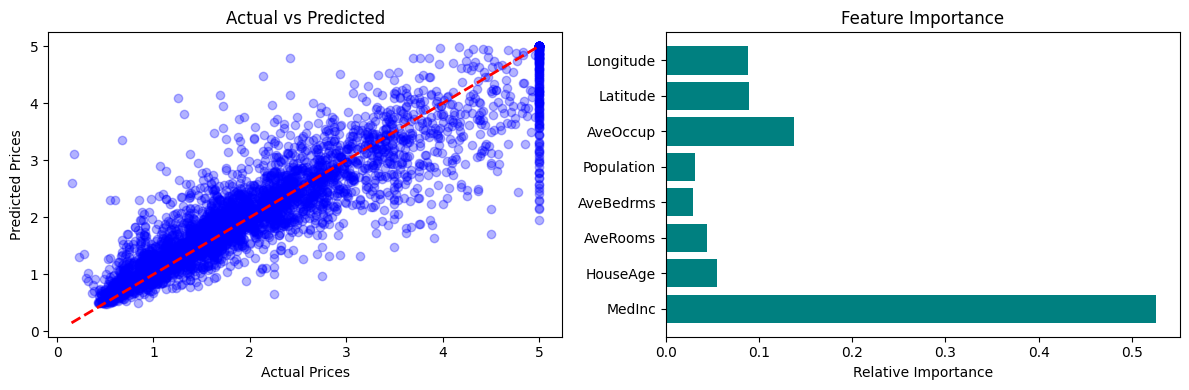

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load & Split Data
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model (Using fewer trees for faster execution)
model = RandomForestRegressor(n_estimators=50, random_state=42).fit(X_train, y_train)

# 3. Predict & Evaluate
y_pred = model.predict(X_test)
print(f"R-squared: {r2_score(y_test, y_pred):.4f} | MSE: {mean_squared_error(y_test, y_pred):.4f}")

# 4. Plotting (Actual vs Predicted & Feature Importance)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Scatter Plot
ax[0].scatter(y_test, y_pred, alpha=0.3, color='blue')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set(title="Actual vs Predicted", xlabel="Actual Prices", ylabel="Predicted Prices")

# Bar Chart
importances = model.feature_importances_
ax[1].barh(X.columns, importances, color='teal')
ax[1].set(title="Feature Importance", xlabel="Relative Importance")

plt.tight_layout()
plt.show()